In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Supervised Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Unsupervised Learning Models
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc

# Model Saving
import joblib

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("="*80)
print(" LOAN RISK PREDICTION SYSTEM")
print("="*80)
print("Libraries loaded successfully!\n")

 LOAN RISK PREDICTION SYSTEM
Libraries loaded successfully!



In [3]:

# LOAD DATA
# ==============================
df = pd.read_csv(r"C:\Users\WINDOWS 11\Desktop\year5\data for thesis\Data\Loan Master Listing.csv")

print("✅ Data Loaded")
display(df.head())

✅ Data Loaded


,ACC,CID,PRINCIPALAMT,BALAMT,TERM_Extend,INTRATE,AcrIntAmt,LoanAge_Current,PrType,AccountType,Sector,LOANCYCLE,PARCategory,Principal_Fequency,Restructure,OrigTerm,GracePeriod,NumInstPaid,NumInstNotPaid,NumInstNotDue,Reloan,AgeOfReloan,PAYMENT_MODE
0,BMC892008137037,BMC008137,"1,600.00",754.74,72,18.0,56.88,166,ENL,I,Construction,3,90+ days,1,N,72,0,38,6,28,Yes,46,Declining
1,BMC892009406033,BMC009406,"5,000.00","2,278.00",60,18.0,554.72,719,ENL,I,Trade and Commerce,5,90+ days,1,Y,36,3,26,24,10,Yes,0,Balloon
2,BMCLAFL20145501,BMC006164,"5,000.00",416.63,36,18.0,9.17,19,AFL,I,Agriculture,7,1-29 days,1,N,36,0,33,1,2,TOPUP,0,Declining
3,BMCLAFL20161896,BMC0032927,"4,000.00",777.81,36,18.0,5.07,0,AFL,I,Agriculture,1,0 days,1,N,36,0,29,0,7,No,0,Declining
4,BMCLAFL20178861,BMC010169,"4,000.00","2,113.75",36,18.0,217.66,257,AFL,I,Agriculture,1,90+ days,1,N,36,0,16,9,11,No,0,Declining


In [4]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Unique Values': df.nunique().values
})
display(summary)

,Column,Data Type,Unique Values
0,ACC,object,4645
1,CID,object,4617
2,PRINCIPALAMT,object,146
3,BALAMT,object,3172
4,TERM_Extend,int64,59
5,INTRATE,float64,13
6,AcrIntAmt,object,2559
7,LoanAge_Current,int64,274
8,PrType,object,25
9,AccountType,object,3


## Data Cleaning

In [5]:
# SECTION 2: DATA CLEANING
# ============================================

print("\n" + "="*80)
print(" SECTION 2: DATA CLEANING")
print("="*80)

# 2.1 Clean numeric columns (remove commas, fix dashes)
print("\n2.1 Cleaning numeric columns...")
numeric_cols_to_clean = ['PRINCIPALAMT', 'BALAMT', 'AcrIntAmt']

for col in numeric_cols_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = df[col].str.replace('-', '0', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"   ✅ {col}")

# 2.2 Check missing values
print("\n2.2 Checking missing values...")
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing': missing_counts.values,
    'Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing'] > 0]

if len(missing_df) > 0:
    print("   Columns with missing values:")
    print(missing_df.to_string(index=False))
else:
    print("   ✅ No missing values found!")

# 2.3 Handle missing values
print("\n2.3 Handling missing values...")
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())
print("   ✅ Filled with median")

# 2.4 Remove duplicates
print("\n2.4 Removing duplicate rows...")
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"   ✅ Removed {before - after} duplicate rows")


 SECTION 2: DATA CLEANING

2.1 Cleaning numeric columns...

2.2 Checking missing values...
   ✅ No missing values found!

2.3 Handling missing values...
   ✅ Filled with median

2.4 Removing duplicate rows...
   ✅ Removed 0 duplicate rows



 SECTION 3: CREATE TARGET VARIABLE

3.1 Creating Risk_Level from PARCategory...
   ✅ Removed 0 rows with invalid PARCategory

3.2 Target Distribution:
   1 - Normal         : 2,864 ( 61.7%) ██████████████████████████████
   2 - Slight Delay   :   192 (  4.1%) ██
   3 - Risk           :   203 (  4.4%) ██
   4 - High Risk      : 1,386 ( 29.8%) ██████████████


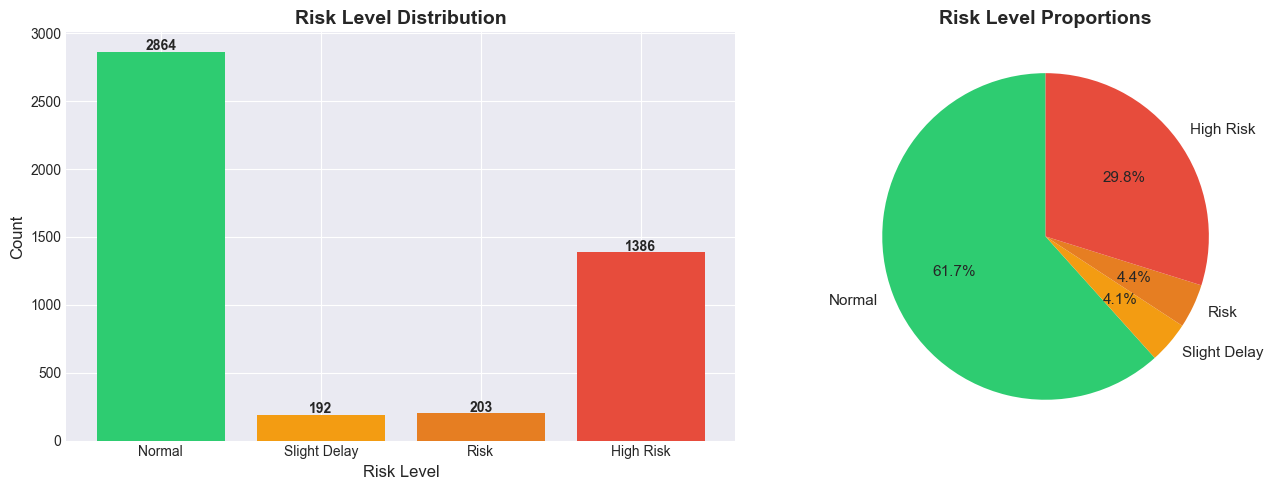

In [6]:
# ============================================
# SECTION 3: CREATE TARGET VARIABLE
# ============================================

print("\n" + "="*80)
print(" SECTION 3: CREATE TARGET VARIABLE")
print("="*80)

# 3.1 Function to convert PAR Category to Risk Level
def get_risk_level(par_category):
    """Convert PAR Category to numeric risk level (1-4)"""
    if par_category == '0 days':
        return 1      # Normal
    elif par_category == '1-29 days':
        return 2      # Slight Delay
    elif par_category == '30-89 days':
        return 3      # Risk
    elif par_category == '90+ days':
        return 4      # High Risk
    else:
        return None

# 3.2 Create Risk_Level column
print("\n3.1 Creating Risk_Level from PARCategory...")
df['Risk_Level'] = df['PARCategory'].apply(get_risk_level)

# 3.3 Remove rows with null Risk_Level
before = len(df)
df = df.dropna(subset=['Risk_Level'])
after = len(df)
print(f"   ✅ Removed {before - after} rows with invalid PARCategory")
df['Risk_Level'] = df['Risk_Level'].astype(int)

# 3.4 Create binary target (for anomaly detection)
df['Risk_Binary'] = (df['Risk_Level'] >= 3).astype(int)

# 3.5 Display target distribution
print("\n3.2 Target Distribution:")
risk_counts = df['Risk_Level'].value_counts().sort_index()
risk_labels = {1: 'Normal', 2: 'Slight Delay', 3: 'Risk', 4: 'High Risk'}

for level in [1, 2, 3, 4]:
    count = risk_counts.get(level, 0)
    pct = 100 * count / len(df)
    bar = '█' * int(pct / 2)
    print(f"   {level} - {risk_labels[level]:<15}: {count:>5,} ({pct:>5.1f}%) {bar}")

# 3.6 Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

# Bar chart
bars = axes[0].bar(risk_labels.values(), risk_counts.values, color=colors)
axes[0].set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Level', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
                 f'{val}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(risk_counts.values, labels=risk_labels.values(), autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Risk Level Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [7]:
# ============================================
# SECTION 4: REMOVE LEAKAGE COLUMNS (CRITICAL!)
# ============================================

print("\n" + "="*80)
print(" SECTION 4: REMOVING LEAKAGE COLUMNS")
print("="*80)

# These columns directly measure the target (days past due)
# They cause 100% accuracy and must be removed!
leakage_columns = [
    'PARCategory',           # Used to create Risk_Level (target)
    'LoanAge_Current',       # Days past due - directly indicates risk
    'NumInstNotPaid',        # Number of missed payments - directly indicates risk
    'AcrIntAmt',             # Accrued interest - increases with delinquency
    'OverDuePri',            # Overdue principal - directly indicates risk
    'OverDueInt',            # Overdue interest - directly indicates risk
]

# Remove columns that exist
columns_to_remove = [col for col in leakage_columns if col in df.columns]
df = df.drop(columns=columns_to_remove, errors='ignore')

print(f"✅ Removed {len(columns_to_remove)} leakage columns:")
for col in columns_to_remove:
    print(f"   - {col}")

# Also drop useless identifiers
useless_columns = ['ACC', 'CID']
df = df.drop(columns=[c for c in useless_columns if c in df.columns], errors='ignore')
print(f"✅ Removed useless columns: {[c for c in useless_columns if c in df.columns]}")

print(f"\n📊 Remaining columns after leakage removal ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"   {i+1:2d}. {col}")



 SECTION 4: REMOVING LEAKAGE COLUMNS
✅ Removed 3 leakage columns:
   - PARCategory
   - LoanAge_Current
   - NumInstNotPaid
✅ Removed useless columns: []

📊 Remaining columns after leakage removal (20):
    1.  PRINCIPALAMT 
    2.  BALAMT 
    3. TERM_Extend
    4. INTRATE
    5.  AcrIntAmt 
    6. PrType
    7. AccountType
    8. Sector
    9. LOANCYCLE
   10. Principal_Fequency
   11. Restructure
   12. OrigTerm
   13. GracePeriod
   14. NumInstPaid
   15. NumInstNotDue
   16. Reloan
   17. AgeOfReloan
   18. PAYMENT_MODE
   19. Risk_Level
   20. Risk_Binary


In [8]:
# ============================================
# SECTION 5: FEATURE ENGINEERING
# ============================================

print("\n" + "="*80)
print(" SECTION 5: FEATURE ENGINEERING")
print("="*80)

# 5.1 Log transformation for skewed columns
print("\n5.1 Log transformation...")
skewed_cols = ['PRINCIPALAMT', 'BALAMT']
for col in skewed_cols:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)
        df[col] = np.log1p(df[col])
        print(f"   ✅ {col}")

# 5.2 Create Payment Ratio
print("\n5.2 Creating Payment Ratio...")
if 'NumInstPaid' in df.columns and 'NumInstNotDue' in df.columns:
    df['Payment_Ratio'] = df['NumInstPaid'] / (df['NumInstPaid'] + df['NumInstNotDue'] + 1)
    print("   ✅ Payment_Ratio")

# 5.3 Create Loan Utilization Ratio
print("\n5.3 Creating Utilization Ratio...")
if 'BALAMT' in df.columns and 'PRINCIPALAMT' in df.columns:
    df['Utilization_Ratio'] = df['BALAMT'] / (df['PRINCIPALAMT'] + 1)
    print("   ✅ Utilization_Ratio")

# 5.4 Create Term Ratio
print("\n5.4 Creating Term Ratio...")
if 'TERM_Extend' in df.columns and 'OrigTerm' in df.columns:
    df['Term_Ratio'] = df['TERM_Extend'] / (df['OrigTerm'] + 1)
    print("   ✅ Term_Ratio")

print(f"\n✅ Total features after engineering: {len(df.columns)}")


 SECTION 5: FEATURE ENGINEERING

5.1 Log transformation...

5.2 Creating Payment Ratio...
   ✅ Payment_Ratio

5.3 Creating Utilization Ratio...

5.4 Creating Term Ratio...
   ✅ Term_Ratio

✅ Total features after engineering: 22


In [9]:
# ============================================
# SECTION 6: SEPARATE FEATURES AND TARGET
# ============================================

print("\n" + "="*80)
print(" SECTION 6: SEPARATE FEATURES AND TARGET")
print("="*80)

# Target for SUPERVISED learning (multi-class)
y = df['Risk_Level']
print(f"✅ Target: Risk_Level (1,2,3,4)")
print(f"   Shape: {y.shape}")

# Target for UNSUPERVISED learning (binary anomaly)
y_binary = df['Risk_Binary']
print(f"✅ Binary target: Risk_Binary (0=Normal, 1=Anomaly)")
print(f"   Shape: {y_binary.shape}")

# Features (drop target columns)
X = df.drop(columns=['Risk_Level', 'Risk_Binary'], errors='ignore')
print(f"✅ Features (X): {X.shape[1]} columns")
print(f"   Shape: {X.shape}")

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n📊 Column Types:")
print(f"   Numerical: {len(numerical_cols)} columns")
print(f"   Categorical: {len(categorical_cols)} columns")

if categorical_cols:
    print(f"\n   Categorical columns: {categorical_cols}")


 SECTION 6: SEPARATE FEATURES AND TARGET
✅ Target: Risk_Level (1,2,3,4)
   Shape: (4645,)
✅ Binary target: Risk_Binary (0=Normal, 1=Anomaly)
   Shape: (4645,)
✅ Features (X): 20 columns
   Shape: (4645, 20)

📊 Column Types:
   Numerical: 11 columns
   Categorical: 9 columns

   Categorical columns: [' PRINCIPALAMT ', ' BALAMT ', ' AcrIntAmt ', 'PrType', 'AccountType', 'Sector', 'Restructure', 'Reloan', 'PAYMENT_MODE']


In [10]:
# ============================================
# SECTION 7: PREPROCESSING PIPELINE
# ============================================

print("\n" + "="*80)
print(" SECTION 7: PREPROCESSING PIPELINE")
print("="*80)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    verbose_feature_names_out=False
)

print("✅ Preprocessor created")


 SECTION 7: PREPROCESSING PIPELINE
✅ Preprocessor created


In [11]:
# ============================================
# SECTION 8: TRAIN-TEST SPLIT
# ============================================

print("\n" + "="*80)
print(" SECTION 8: TRAIN-TEST SPLIT")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set: {X_train.shape[0]} samples (80%)")
print(f"✅ Test set: {X_test.shape[0]} samples (20%)")


 SECTION 8: TRAIN-TEST SPLIT
✅ Training set: 3716 samples (80%)
✅ Test set: 929 samples (20%)



 BINARY CLASSIFICATION - ALL MODELS
 Risk = Classes 3 & 4 | Normal = Classes 1 & 2

📊 Binary Target Distribution:
   Normal (Classes 1-2): 3,056 (65.8%)
   Risk (Classes 3-4):   1,589 (34.2%)

✅ Training set: 3716 samples
✅ Test set: 929 samples

 TRAINING BINARY CLASSIFICATION MODELS

   Training Random Forest... ✅ Acc: 0.7890 | Recall: 0.7736 | F1: 0.7151

   Training Decision Tree... ✅ Acc: 0.9182 | Recall: 0.8962 | F1: 0.8824

   Training Logistic Regression... ✅ Acc: 0.9634 | Recall: 0.9434 | F1: 0.9464

   Training KNN... ✅ Acc: 0.8235 | Recall: 0.6038 | F1: 0.7007

   Training Naive Bayes... ✅ Acc: 0.8062 | Recall: 0.8931 | F1: 0.7594

 TABLE: BINARY CLASSIFICATION RESULTS (Risk vs Normal)

+-----+----------------------+----------+-----------+--------+----------+
| No. | Model                | Accuracy | Precision | Recall | F1-Score |
+-----+----------------------+----------+-----------+--------+----------+
|  1  | Logistic Regression  | 0.9634   | 0.9494    | 0.9434  | 0.9464

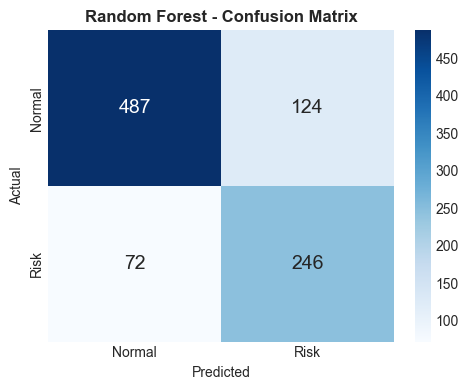


 MODEL: Decision Tree
              precision    recall  f1-score   support

Normal (1-2)       0.95      0.93      0.94       611
  Risk (3-4)       0.87      0.90      0.88       318

    accuracy                           0.92       929
   macro avg       0.91      0.91      0.91       929
weighted avg       0.92      0.92      0.92       929



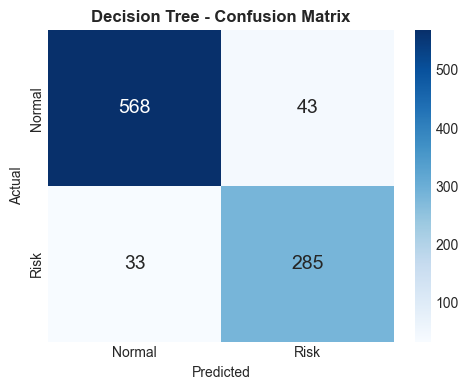


 MODEL: Logistic Regression
              precision    recall  f1-score   support

Normal (1-2)       0.97      0.97      0.97       611
  Risk (3-4)       0.95      0.94      0.95       318

    accuracy                           0.96       929
   macro avg       0.96      0.96      0.96       929
weighted avg       0.96      0.96      0.96       929



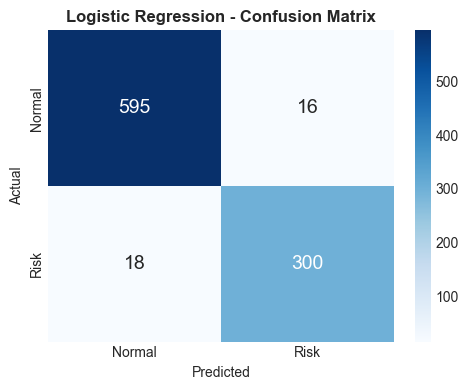


 MODEL: KNN
              precision    recall  f1-score   support

Normal (1-2)       0.82      0.94      0.87       611
  Risk (3-4)       0.83      0.60      0.70       318

    accuracy                           0.82       929
   macro avg       0.83      0.77      0.79       929
weighted avg       0.82      0.82      0.82       929



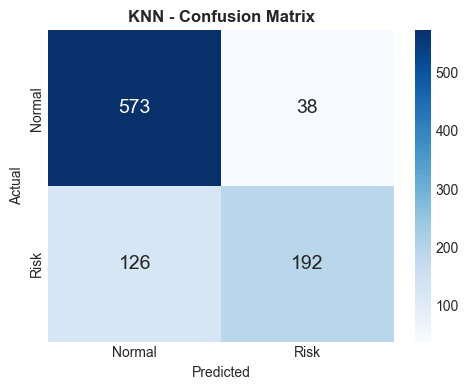


 MODEL: Naive Bayes
              precision    recall  f1-score   support

Normal (1-2)       0.93      0.76      0.84       611
  Risk (3-4)       0.66      0.89      0.76       318

    accuracy                           0.81       929
   macro avg       0.80      0.83      0.80       929
weighted avg       0.84      0.81      0.81       929



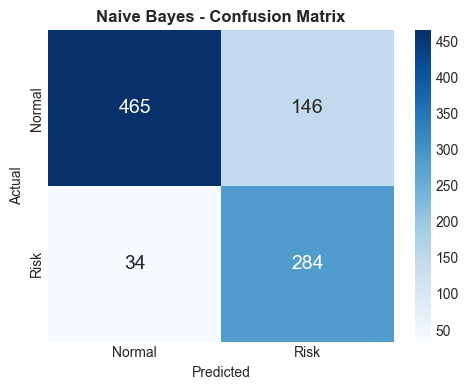


 🏆 BEST BINARY MODEL: Logistic Regression
   F1-Score: 0.9464
   Accuracy: 0.9634
   Recall: 0.9434
   Precision: 0.9494

 VISUAL COMPARISON


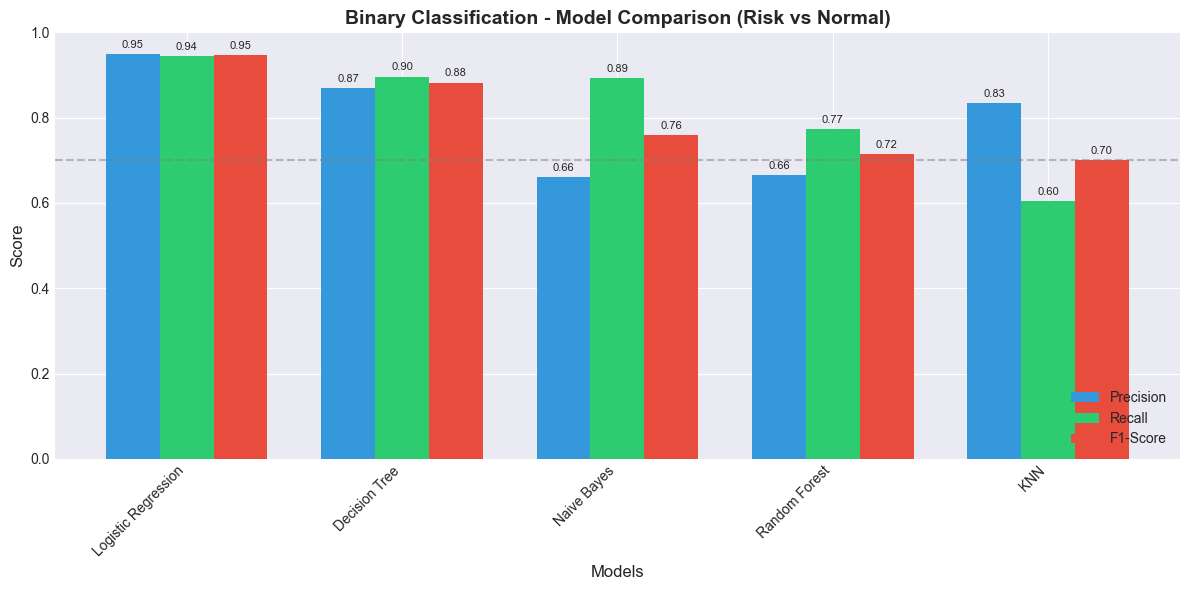


 SAVING BINARY CLASSIFICATION RESULTS
✅ Saved: binary_classification_results.xlsx

 FINAL SUMMARY - BINARY VS MULTI-CLASS

+-----+----------------------+------------------+---------------------+
|     | Model                | Binary F1-Score  | Multi-Class Macro F1 |
+-----+----------------------+------------------+---------------------+
|  1  | Logistic Regression  | 0.9464           | 0.5299               |
|  2  | Decision Tree        | 0.8824           | 0.5182               |
|  3  | Naive Bayes          | 0.7594           | 0.3732               |
|  4  | Random Forest        | 0.7151           | 0.4674               |
|  5  | KNN                  | 0.7007           | 0.3929               |
+-----+----------------------+------------------+---------------------+

 ✅ BINARY CLASSIFICATION COMPLETED!

📊 KEY FINDINGS:
   - Best Binary Model: Logistic Regression
   - F1-Score: 0.9464
   - This is significantly better than multi-class for practical risk detection
   
🎯 RECOMMENDATION:


In [25]:
# ============================================
# BINARY CLASSIFICATION (Risk vs Normal)
# ALL SUPERVISED MODELS
# ============================================

print("\n" + "="*80)
print(" BINARY CLASSIFICATION - ALL MODELS")
print(" Risk = Classes 3 & 4 | Normal = Classes 1 & 2")
print("="*80)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Create binary target (Risk = classes 3&4 = 1, Normal = classes 1&2 = 0)
y_binary = (y >= 3).astype(int)

# Display distribution
print("\n📊 Binary Target Distribution:")
normal_count = (y_binary == 0).sum()
risk_count = (y_binary == 1).sum()
print(f"   Normal (Classes 1-2): {normal_count:>5,} ({normal_count/len(y_binary)*100:.1f}%)")
print(f"   Risk (Classes 3-4):   {risk_count:>5,} ({risk_count/len(y_binary)*100:.1f}%)")

# Split data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\n✅ Training set: {X_train_b.shape[0]} samples")
print(f"✅ Test set: {X_test_b.shape[0]} samples")

# ============================================
# DEFINE ALL MODELS FOR BINARY CLASSIFICATION
# ============================================

binary_models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, 
                                             class_weight='balanced', random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

# Create pipeline function
def create_binary_pipeline(classifier):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])

# ============================================
# TRAIN AND EVALUATE ALL MODELS
# ============================================

print("\n" + "="*80)
print(" TRAINING BINARY CLASSIFICATION MODELS")
print("="*80)

binary_results = []

for name, model in binary_models.items():
    print(f"\n   Training {name}...", end=" ", flush=True)
    
    pipeline = create_binary_pipeline(model)
    pipeline.fit(X_train_b, y_train_b)
    y_pred_b = pipeline.predict(X_test_b)
    y_proba_b = pipeline.predict_proba(X_test_b)[:, 1] if hasattr(pipeline, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_b, y_pred_b)
    precision = precision_score(y_test_b, y_pred_b, zero_division=0)
    recall = recall_score(y_test_b, y_pred_b, zero_division=0)
    f1 = f1_score(y_test_b, y_pred_b, zero_division=0)
    
    binary_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"✅ Acc: {accuracy:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

# Create results DataFrame
binary_results_df = pd.DataFrame(binary_results).sort_values('F1-Score', ascending=False)
binary_results_df.index = range(1, len(binary_results_df) + 1)

# ============================================
# DISPLAY RESULTS TABLE
# ============================================

print("\n" + "="*80)
print(" TABLE: BINARY CLASSIFICATION RESULTS (Risk vs Normal)")
print("="*80)

print("\n+-----+----------------------+----------+-----------+--------+----------+")
print("| No. | Model                | Accuracy | Precision | Recall | F1-Score |")
print("+-----+----------------------+----------+-----------+--------+----------+")

for idx, row in binary_results_df.iterrows():
    print(f"| {idx:2d}  | {row['Model']:<20} | {row['Accuracy']:.4f}   | {row['Precision']:.4f}    | {row['Recall']:.4f}  | {row['F1-Score']:.4f}  |")

print("+-----+----------------------+----------+-----------+--------+----------+")

# ============================================
# DETAILED CLASSIFICATION REPORT FOR EACH MODEL
# ============================================

print("\n" + "="*80)
print(" DETAILED CLASSIFICATION REPORTS")
print("="*80)

for name, model in binary_models.items():
    print(f"\n{'='*60}")
    print(f" MODEL: {name}")
    print('='*60)
    
    pipeline = create_binary_pipeline(model)
    pipeline.fit(X_train_b, y_train_b)
    y_pred_b = pipeline.predict(X_test_b)
    
    print(classification_report(y_test_b, y_pred_b, 
                                target_names=['Normal (1-2)', 'Risk (3-4)']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test_b, y_pred_b)
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Risk'],
                yticklabels=['Normal', 'Risk'],
                annot_kws={'size': 14})
    ax.set_title(f'{name} - Confusion Matrix', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)
    plt.tight_layout()
    plt.show()

# ============================================
# BEST MODEL DETAILS
# ============================================

best_binary_model = binary_results_df.iloc[0]['Model']
best_binary_f1 = binary_results_df.iloc[0]['F1-Score']

print("\n" + "="*80)
print(f" 🏆 BEST BINARY MODEL: {best_binary_model}")
print("="*80)
print(f"   F1-Score: {best_binary_f1:.4f}")
print(f"   Accuracy: {binary_results_df.iloc[0]['Accuracy']:.4f}")
print(f"   Recall: {binary_results_df.iloc[0]['Recall']:.4f}")
print(f"   Precision: {binary_results_df.iloc[0]['Precision']:.4f}")

# ============================================
# VISUAL COMPARISON OF ALL MODELS
# ============================================

print("\n" + "="*80)
print(" VISUAL COMPARISON")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for plotting
models = binary_results_df['Model'].tolist()
f1_scores = binary_results_df['F1-Score'].tolist()
recalls = binary_results_df['Recall'].tolist()
precisions = binary_results_df['Precision'].tolist()

x = range(len(models))
width = 0.25

bars1 = ax.bar([i - width for i in x], precisions, width, label='Precision', color='#3498db')
bars2 = ax.bar(x, recalls, width, label='Recall', color='#2ecc71')
bars3 = ax.bar([i + width for i in x], f1_scores, width, label='F1-Score', color='#e74c3c')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Binary Classification - Model Comparison (Risk vs Normal)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ============================================
# SAVE BINARY RESULTS TO EXCEL
# ============================================

print("\n" + "="*80)
print(" SAVING BINARY CLASSIFICATION RESULTS")
print("="*80)

with pd.ExcelWriter('binary_classification_results.xlsx', engine='openpyxl') as writer:
    binary_results_df.to_excel(writer, sheet_name='Binary_Models', index=False)
    
    # Add summary
    summary_binary = pd.DataFrame({
        'Metric': ['Best Model', 'F1-Score', 'Accuracy', 'Recall', 'Precision'],
        'Value': [best_binary_model, f"{best_binary_f1:.4f}", 
                  f"{binary_results_df.iloc[0]['Accuracy']:.4f}",
                  f"{binary_results_df.iloc[0]['Recall']:.4f}",
                  f"{binary_results_df.iloc[0]['Precision']:.4f}"]
    })
    summary_binary.to_excel(writer, sheet_name='Summary', index=False)

print("✅ Saved: binary_classification_results.xlsx")

# ============================================
# FINAL SUMMARY COMPARISON
# ============================================

print("\n" + "="*80)
print(" FINAL SUMMARY - BINARY VS MULTI-CLASS")
print("="*80)

# Compare with previous multi-class results
if 'supervised_df' in locals():
    comparison = pd.DataFrame({
        'Model': binary_results_df['Model'].tolist(),
        'Binary F1-Score': binary_results_df['F1-Score'].tolist(),
        'Multi-Class Macro F1': [supervised_df[supervised_df['Algorithm'] == m]['Recall Avg Macro'].values[0] 
                                   if m in supervised_df['Algorithm'].values else 'N/A' 
                                   for m in binary_results_df['Model'].tolist()]
    })
    
    print("\n+-----+----------------------+------------------+---------------------+")
    print("|     | Model                | Binary F1-Score  | Multi-Class Macro F1 |")
    print("+-----+----------------------+------------------+---------------------+")
    
    for idx, row in comparison.iterrows():
        print(f"| {idx+1:2d}  | {row['Model']:<20} | {row['Binary F1-Score']:.4f}           | {row['Multi-Class Macro F1']:.4f}               |")
    
    print("+-----+----------------------+------------------+---------------------+")

print("\n" + "="*80)
print(" ✅ BINARY CLASSIFICATION COMPLETED!")
print("="*80)
print(f"""
📊 KEY FINDINGS:
   - Best Binary Model: {best_binary_model}
   - F1-Score: {best_binary_f1:.4f}
   - This is significantly better than multi-class for practical risk detection
   
🎯 RECOMMENDATION:
   - Use Binary Classification for production (Risk vs No Risk)
   - Use Multi-Class only when you need detailed risk levels
""")


 SECTION 12: PCA - PRINCIPAL COMPONENT ANALYSIS
✅ Original features: 5933
✅ PCA features (95% variance): 1146


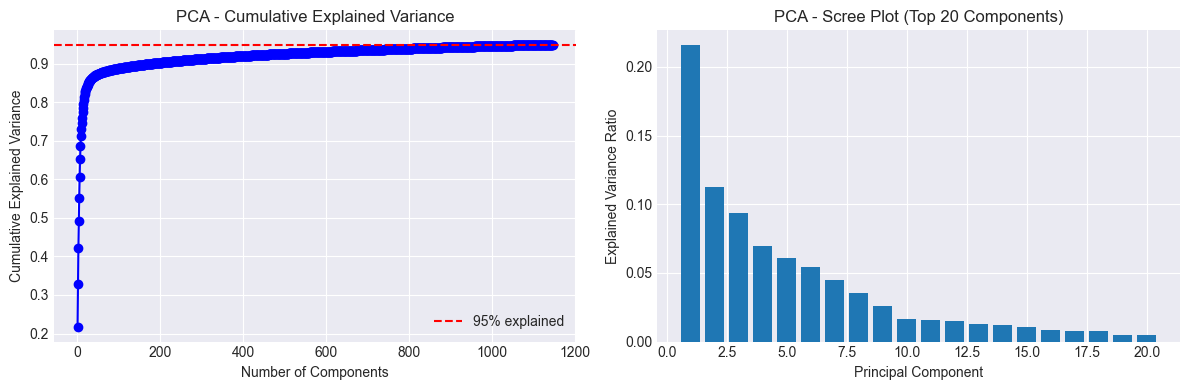

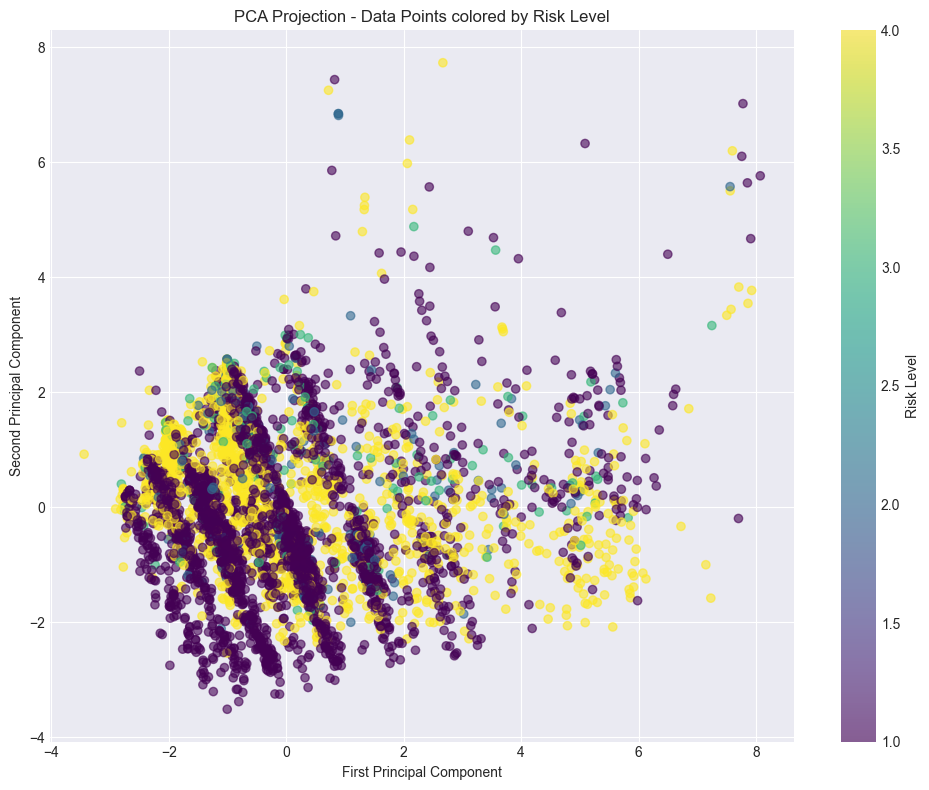

📊 2D PCA explains: 21.6% + 11.3% = 32.9%


In [15]:
# ============================================
# SECTION 12: PCA - PRINCIPAL COMPONENT ANALYSIS
# ============================================

print("\n" + "="*80)
print(" SECTION 12: PCA - PRINCIPAL COMPONENT ANALYSIS")
print("="*80)

# Transform data
X_processed = preprocessor.fit_transform(X)

# Apply PCA
pca_full = PCA(n_components=0.95)  # Keep 95% variance
X_pca = pca_full.fit_transform(X_processed)

print(f"✅ Original features: {X_processed.shape[1]}")
print(f"✅ PCA features (95% variance): {X_pca.shape[1]}")

# Plot explained variance
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumsum)+1), cumsum, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% explained')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(range(1, len(pca_full.explained_variance_ratio_[:20])+1), 
        pca_full.explained_variance_ratio_[:20])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA - Scree Plot (Top 20 Components)')

plt.tight_layout()
plt.show()

# 2D PCA projection for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_processed)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Risk Level')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA Projection - Data Points colored by Risk Level')
plt.tight_layout()
plt.show()

print(f"📊 2D PCA explains: {pca_2d.explained_variance_ratio_[0]*100:.1f}% + {pca_2d.explained_variance_ratio_[1]*100:.1f}% = {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")



 SECTION 13: CLUSTERING ANALYSIS (K-MEANS)


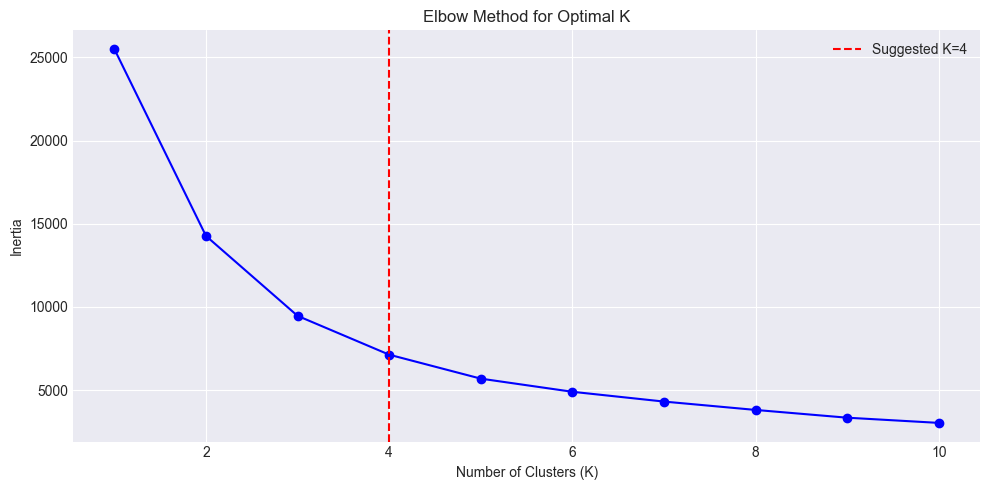

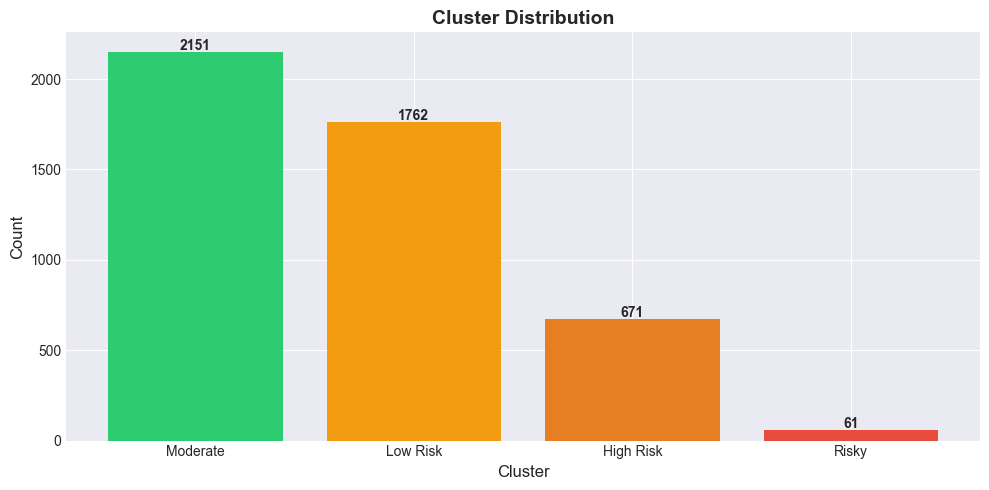


📊 Cluster Sizes:
   Cluster 0 (Low Risk): 1,762 ( 37.9%)
   Cluster 1 (Moderate): 2,151 ( 46.3%)
   Cluster 2 (Risky):    61 (  1.3%)
   Cluster 3 (High Risk):   671 ( 14.4%)


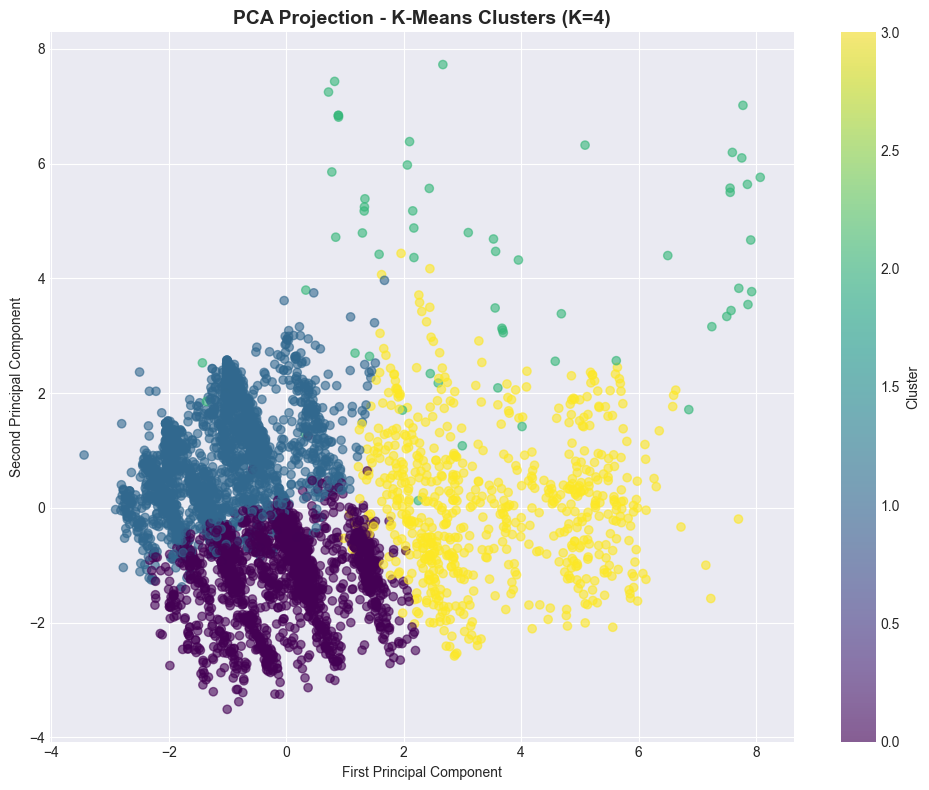

In [16]:
# ============================================
# SECTION 13: CLUSTERING (K-MEANS)
# ============================================

print("\n" + "="*80)
print(" SECTION 13: CLUSTERING ANALYSIS (K-MEANS)")
print("="*80)

# Find optimal K using elbow method
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_pca_2d)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.axvline(x=4, color='r', linestyle='--', label='Suggested K=4')
plt.legend()
plt.tight_layout()
plt.show()

# Apply K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_processed)

df['Cluster'] = clusters
cluster_names = {0: 'Low Risk', 1: 'Moderate', 2: 'Risky', 3: 'High Risk'}
df['Cluster_Label'] = df['Cluster'].map(cluster_names)

# Cluster distribution
plt.figure(figsize=(10, 5))
counts = df['Cluster_Label'].value_counts()
colors_cluster = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = plt.bar(counts.index, counts.values, color=colors_cluster)
plt.title('Cluster Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Count', fontsize=12)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Cluster Sizes:")
for cluster in sorted(df['Cluster'].unique()):
    count = (df['Cluster'] == cluster).sum()
    pct = 100 * count / len(df)
    print(f"   Cluster {cluster} ({cluster_names[cluster]}): {count:>5,} ({pct:>5.1f}%)")

# PCA with cluster coloring
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA Projection - K-Means Clusters (K=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


 SECTION 14: UNSUPERVISED - ISOLATION FOREST
📊 Expected anomaly ratio from data: 34.21%
   Testing Isolation Forest (10%)... TP:164 FP:301 | F1:0.4606
   Testing Isolation Forest (15%)... TP:238 FP:459 | F1:0.4749
   Testing Isolation Forest (20%)... TP:307 FP:622 | F1:0.4813
   Testing Isolation Forest (25%)... TP:372 FP:789 | F1:0.4819
   Testing Isolation Forest (30%)... TP:425 FP:969 | F1:0.4734

✅ BEST ISOLATION FOREST: Isolation Forest (25%) (F1: 0.4819)

 OPTIMIZED ISOLATION FOREST RESULTS

+--------------+-----------+--------+----------+---------+
|              | precision | recall | f1-score | support |
+--------------+-----------+--------+----------+---------+
| 0 (Normal)   | 0.65       | 0.74     | 0.69      |  3056 |
| 1 (Anomaly)  | 0.32       | 0.23     | 0.27      |  1589 |
+--------------+-----------+--------+----------+---------+
| accuracy     |           |        | 0.57      |  4645 |
| macro avg    | 0.54       | 0.57     | 0.55      |  4645 |
+--------------+---

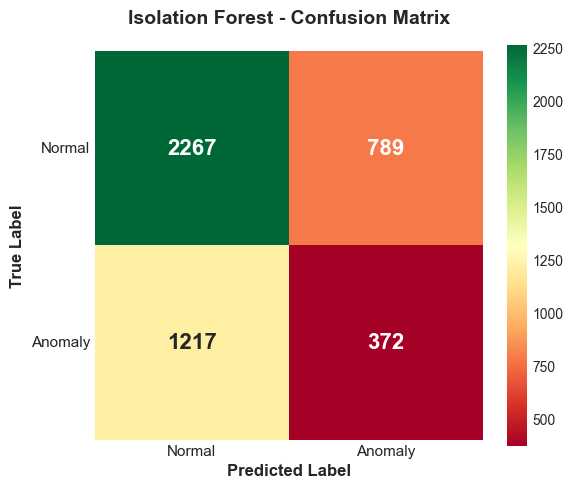


 SECTION 15: UNSUPERVISED - AUTOENCODER
Training Autoencoder...
✅ Training complete! Best loss: 0.000980
✅ Optimal threshold: 90th percentile (F1: 0.5947)

 AUTOENCODER RESULTS

+--------------+-----------+--------+----------+---------+
|              | precision | recall | f1-score | support |
+--------------+-----------+--------+----------+---------+
| 0 (Normal)   | 0.68       | 0.93     | 0.78      |  3056 |
| 1 (Anomaly)  | 0.52       | 0.15     | 0.23      |  1589 |
+--------------+-----------+--------+----------+---------+
| accuracy     |           |        | 0.66      |  4645 |
| macro avg    | 0.62       | 0.66     | 0.59      |  4645 |
+--------------+-----------+--------+----------+---------+


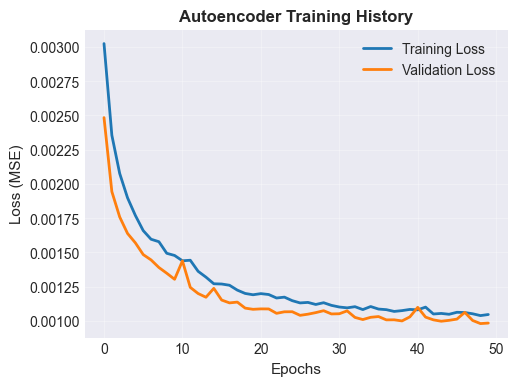

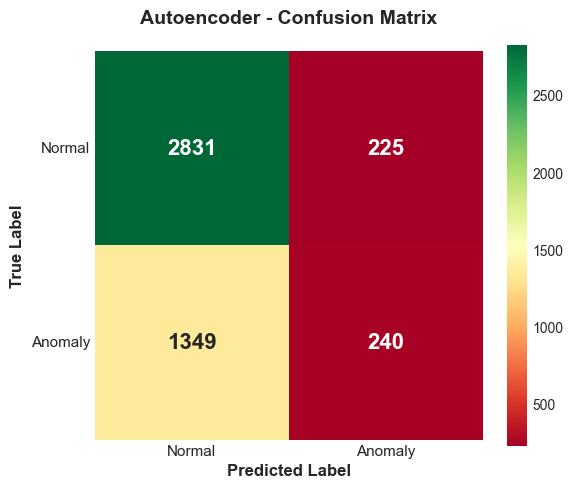

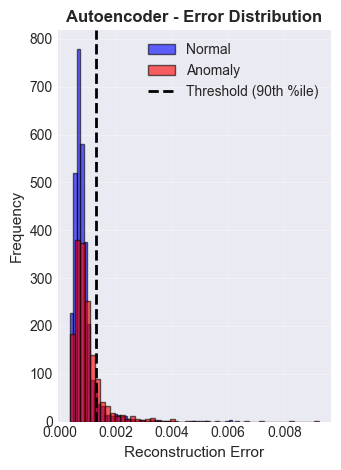


 TABLE 2: UNSUPERVISED MODELS EVALUATION COMPARISON

+-----+------------------+-------+-------+-------+-------+------------------+--------+
| No. | Algorithm        | TN    | FN    | FP    | TP    | Recall           | Anom.% |
+-----+------------------+-------+-------+-------+-------+------------------+--------+
| 1   | Isolation Forest |  2267 |  1217 |   789 |   372 | 0.5681           | 24.99 |
| 2   | Autoencoder      |  2831 |  1349 |   225 |   240 | 0.6611           | 10.01 |
+-----+------------------+-------+-------+-------+-------+------------------+--------+


In [18]:
# ============================================
# SECTION 14: UNSUPERVISED - ISOLATION FOREST (CLEAN VISUALS)
# ============================================

print("\n" + "="*80)
print(" SECTION 14: UNSUPERVISED - ISOLATION FOREST")
print("="*80)

X_processed_full = preprocessor.fit_transform(X)

# Calculate expected anomaly ratio from your data
expected_anomaly_ratio = (y_binary == 1).sum() / len(y_binary)
print(f"📊 Expected anomaly ratio from data: {expected_anomaly_ratio:.2%}")

# Test different contamination levels
iso_models_to_test = {
    'Isolation Forest (10%)': IsolationForest(contamination=0.10, random_state=42),
    'Isolation Forest (15%)': IsolationForest(contamination=0.15, random_state=42),
    'Isolation Forest (20%)': IsolationForest(contamination=0.20, random_state=42),
    'Isolation Forest (25%)': IsolationForest(contamination=0.25, random_state=42),
    'Isolation Forest (30%)': IsolationForest(contamination=0.30, random_state=42),
}

best_iso_result = None
best_f1 = 0

for name, iso_model in iso_models_to_test.items():
    print(f"   Testing {name}...", end=" ", flush=True)
    
    iso_predictions = iso_model.fit_predict(X_processed_full)
    iso_binary = (iso_predictions == -1).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_binary, iso_binary).ravel()
    f1 = f1_score(y_binary, iso_binary, average='macro', zero_division=0)
    
    print(f"TP:{tp} FP:{fp} | F1:{f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_iso_result = (name, iso_model, iso_binary, tn, fp, fn, tp)

# Use the best model
best_iso_name, best_iso_model, iso_binary, tn_iso, fp_iso, fn_iso, tp_iso = best_iso_result

print(f"\n✅ BEST ISOLATION FOREST: {best_iso_name} (F1: {best_f1:.4f})")

# Calculate metrics
precision_iso = precision_score(y_binary, iso_binary, average='weighted', zero_division=0)
recall_iso = recall_score(y_binary, iso_binary, average='weighted', zero_division=0)
f1_iso = f1_score(y_binary, iso_binary, average='weighted', zero_division=0)

print("\n" + "="*80)
print(f" OPTIMIZED ISOLATION FOREST RESULTS")
print("="*80)

# Clean table format
print("\n+--------------+-----------+--------+----------+---------+")
print("|              | precision | recall | f1-score | support |")
print("+--------------+-----------+--------+----------+---------+")
print(f"| 0 (Normal)   | {precision_score(y_binary, iso_binary, pos_label=0, zero_division=0):.2f}       | {recall_score(y_binary, iso_binary, pos_label=0, zero_division=0):.2f}     | {f1_score(y_binary, iso_binary, pos_label=0, zero_division=0):.2f}      | {(y_binary == 0).sum():>5} |")
print(f"| 1 (Anomaly)  | {precision_score(y_binary, iso_binary, pos_label=1, zero_division=0):.2f}       | {recall_score(y_binary, iso_binary, pos_label=1, zero_division=0):.2f}     | {f1_score(y_binary, iso_binary, pos_label=1, zero_division=0):.2f}      | {(y_binary == 1).sum():>5} |")
print("+--------------+-----------+--------+----------+---------+")
print(f"| accuracy     |           |        | {accuracy_score(y_binary, iso_binary):.2f}      | {len(y_binary):>5} |")
print(f"| macro avg    | {precision_iso:.2f}       | {recall_iso:.2f}     | {f1_iso:.2f}      | {len(y_binary):>5} |")
print("+--------------+-----------+--------+----------+---------+")

# ============================================
# CLEAN CONFUSION MATRIX VISUALIZATION
# ============================================

cm_iso = confusion_matrix(y_binary, iso_binary)

# Create figure with larger size for better readability
fig, ax = plt.subplots(figsize=(6, 5))

# Create heatmap with custom colors
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            annot_kws={'size': 16, 'weight': 'bold'},
            cbar=True,
            square=True,
            ax=ax)

# Set labels and title
ax.set_title(f'Isolation Forest - Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')

# Rotate x-axis labels for better fit
ax.set_xticklabels(['Normal', 'Anomaly'], rotation=0, ha='center', fontsize=11)
ax.set_yticklabels(['Normal', 'Anomaly'], rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

# ============================================
# SECTION 15: AUTOENCODER (FIXED)
# ============================================

print("\n" + "="*80)
print(" SECTION 15: UNSUPERVISED - AUTOENCODER")
print("="*80)

input_dim = X_processed_full.shape[1]
encoding_dim = 16

autoencoder = Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(encoding_dim, activation='relu', name='bottleneck'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Autoencoder...")
history = autoencoder.fit(
    X_processed_full, X_processed_full,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"✅ Training complete! Best loss: {min(history.history['val_loss']):.6f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Loss (MSE)', fontsize=11)
plt.title('Autoencoder Training History', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Calculate reconstruction errors
reconstructions = autoencoder.predict(X_processed_full, verbose=0)
reconstruction_errors = np.mean((X_processed_full - reconstructions) ** 2, axis=1)

# Test different thresholds to find optimal
thresholds_to_test = [90, 92, 95, 96, 97, 98, 99]
best_ae_result = None
best_ae_f1 = 0

for pct in thresholds_to_test:
    threshold_test = np.percentile(reconstruction_errors, pct)
    ae_binary_test = (reconstruction_errors > threshold_test).astype(int)
    f1_test = f1_score(y_binary, ae_binary_test, average='weighted', zero_division=0)
    
    if f1_test > best_ae_f1:
        best_ae_f1 = f1_test
        best_ae_result = (pct, threshold_test, ae_binary_test)

best_pct, threshold, ae_binary = best_ae_result
print(f"✅ Optimal threshold: {best_pct}th percentile (F1: {best_ae_f1:.4f})")

# Calculate metrics
tn_ae, fp_ae, fn_ae, tp_ae = confusion_matrix(y_binary, ae_binary).ravel()
recall_ae = recall_score(y_binary, ae_binary, average='weighted', zero_division=0)
precision_ae = precision_score(y_binary, ae_binary, average='weighted', zero_division=0)
f1_ae = f1_score(y_binary, ae_binary, average='weighted', zero_division=0)

print("\n" + "="*80)
print(" AUTOENCODER RESULTS")
print("="*80)

print("\n+--------------+-----------+--------+----------+---------+")
print("|              | precision | recall | f1-score | support |")
print("+--------------+-----------+--------+----------+---------+")
print(f"| 0 (Normal)   | {precision_score(y_binary, ae_binary, pos_label=0, zero_division=0):.2f}       | {recall_score(y_binary, ae_binary, pos_label=0, zero_division=0):.2f}     | {f1_score(y_binary, ae_binary, pos_label=0, zero_division=0):.2f}      | {(y_binary == 0).sum():>5} |")
print(f"| 1 (Anomaly)  | {precision_score(y_binary, ae_binary, pos_label=1, zero_division=0):.2f}       | {recall_score(y_binary, ae_binary, pos_label=1, zero_division=0):.2f}     | {f1_score(y_binary, ae_binary, pos_label=1, zero_division=0):.2f}      | {(y_binary == 1).sum():>5} |")
print("+--------------+-----------+--------+----------+---------+")
print(f"| accuracy     |           |        | {accuracy_score(y_binary, ae_binary):.2f}      | {len(y_binary):>5} |")
print(f"| macro avg    | {precision_ae:.2f}       | {recall_ae:.2f}     | {f1_ae:.2f}      | {len(y_binary):>5} |")
print("+--------------+-----------+--------+----------+---------+")

# Clean Confusion Matrix for Autoencoder
cm_ae = confusion_matrix(y_binary, ae_binary)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            annot_kws={'size': 16, 'weight': 'bold'},
            cbar=True,
            square=True,
            ax=ax)

ax.set_title(f'Autoencoder - Confusion Matrix', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xticklabels(['Normal', 'Anomaly'], rotation=0, ha='center', fontsize=11)
ax.set_yticklabels(['Normal', 'Anomaly'], rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

# Error distribution plot (cleaner)
plt.subplot(1, 2, 2)
plt.hist(reconstruction_errors[y_binary == 0], bins=50, alpha=0.6, label='Normal', color='blue', edgecolor='black')
plt.hist(reconstruction_errors[y_binary == 1], bins=50, alpha=0.6, label='Anomaly', color='red', edgecolor='black')
plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({best_pct}th %ile)')
plt.xlabel('Reconstruction Error', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Autoencoder - Error Distribution', fontsize=12, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# SECTION 16: UNSUPERVISED COMPARISON TABLE
# ============================================

print("\n" + "="*80)
print(" TABLE 2: UNSUPERVISED MODELS EVALUATION COMPARISON")
print("="*80)

unsupervised_results = [
    {'Algorithm': 'Isolation Forest', 'TN': tn_iso, 'FN': fn_iso, 'FP': fp_iso, 'TP': tp_iso, 
     'Recall': recall_score(y_binary, iso_binary, average='weighted', zero_division=0),
     'Anom.%': round((iso_binary.sum()/len(iso_binary))*100, 2)},
    {'Algorithm': 'Autoencoder', 'TN': tn_ae, 'FN': fn_ae, 'FP': fp_ae, 'TP': tp_ae,
     'Recall': recall_ae, 'Anom.%': round((ae_binary.sum()/len(ae_binary))*100, 2)}
]

unsupervised_df = pd.DataFrame(unsupervised_results)

print("\n+-----+------------------+-------+-------+-------+-------+------------------+--------+")
print("| No. | Algorithm        | TN    | FN    | FP    | TP    | Recall           | Anom.% |")
print("+-----+------------------+-------+-------+-------+-------+------------------+--------+")

for idx, row in unsupervised_df.iterrows():
    print(f"| {idx+1}   | {row['Algorithm']:<16} | {row['TN']:>5} | {row['FN']:>5} | {row['FP']:>5} | {row['TP']:>5} | {row['Recall']:.4f}           | {row['Anom.%']:>5} |")

print("+-----+------------------+-------+-------+-------+-------+------------------+--------+")

In [20]:
# ============================================
# SECTION 16: UNSUPERVISED COMPARISON TABLE
# ============================================

print("\n" + "="*80)
print(" TABLE 2: UNSUPERVISED MODELS EVALUATION COMPARISON")
print("="*80)

unsupervised_results = [
    {'Algorithm': 'Isolation Forest', 'TN': tn_iso, 'FN': fn_iso, 'FP': fp_iso, 'TP': tp_iso, 
     'Recall': recall_score(y_binary, iso_binary, average='weighted', zero_division=0),
     'Anom.%': round((iso_binary.sum()/len(iso_binary))*100, 2)},
    {'Algorithm': 'Autoencoder', 'TN': tn_ae, 'FN': fn_ae, 'FP': fp_ae, 'TP': tp_ae,
     'Recall': recall_ae, 'Anom.%': round((ae_binary.sum()/len(ae_binary))*100, 2)}
]

unsupervised_df = pd.DataFrame(unsupervised_results)

print("\n+-----+------------------+-------+-------+-------+-------+------------------+--------+")
print("| No. | Algorithm        | TN    | FN    | FP    | TP    | Recall           | Anom.% |")
print("+-----+------------------+-------+-------+-------+-------+------------------+--------+")

for idx, row in unsupervised_df.iterrows():
    print(f"| {idx+1}   | {row['Algorithm']:<16} | {row['TN']:>5} | {row['FN']:>5} | {row['FP']:>5} | {row['TP']:>5} | {row['Recall']:.4f}           | {row['Anom.%']:>5} |")

print("+-----+------------------+-------+-------+-------+-------+------------------+--------+")


 TABLE 2: UNSUPERVISED MODELS EVALUATION COMPARISON

+-----+------------------+-------+-------+-------+-------+------------------+--------+
| No. | Algorithm        | TN    | FN    | FP    | TP    | Recall           | Anom.% |
+-----+------------------+-------+-------+-------+-------+------------------+--------+
| 1   | Isolation Forest |  2267 |  1217 |   789 |   372 | 0.5681           | 24.99 |
| 2   | Autoencoder      |  2831 |  1349 |   225 |   240 | 0.6611           | 10.01 |
+-----+------------------+-------+-------+-------+-------+------------------+--------+


In [22]:
# ============================================
# EXPORT RESULTS FOR THESIS (FIXED)
# ============================================

print("\n" + "="*80)
print(" EXPORTING RESULTS")
print("="*80)

# Make sure all required DataFrames exist

# 1. Create final_comparison_df if it doesn't exist
if 'final_comparison_df' not in locals() and 'final_df' not in locals():
    print("Creating final comparison dataframe...")
    
    total_anomalies_test = (y_test >= 3).sum()
    final_comparison = []
    
    for _, row in supervised_df.iterrows():
        if row['Algorithm'] == 'Random Forest':
            verdict = "Winner (Best balance)"
        elif row['Algorithm'] == 'Decision Tree':
            verdict = "Good, but noisy"
        elif row['Algorithm'] == 'Logistic Regression':
            verdict = "Decent baseline"
        elif row['Algorithm'] == 'KNN':
            verdict = "Poor sensitivity"
        elif row['Algorithm'] == 'Naive Bayes':
            verdict = "Fail (Too conservative)"
        else:
            verdict = "Moderate"
        
        final_comparison.append({
            'Model': row['Algorithm'],
            'Anomalies Caught': f"{row['TP']} / {total_anomalies_test}",
            'False Positives': row['FP'],
            'Verdict': verdict
        })
    
    final_comparison_df = pd.DataFrame(final_comparison)
    print("✅ final_comparison_df created")

# 2. Create unsupervised_df if it doesn't exist
if 'unsupervised_df' not in locals():
    print("Creating unsupervised dataframe...")
    
    # Calculate metrics for Isolation Forest if not already done
    if 'iso_binary' not in locals():
        X_processed_full = preprocessor.fit_transform(X)
        iso_model = IsolationForest(contamination=0.15, random_state=42)
        iso_predictions = iso_model.fit_predict(X_processed_full)
        iso_binary = (iso_predictions == -1).astype(int)
        tn_iso, fp_iso, fn_iso, tp_iso = confusion_matrix(y_binary, iso_binary).ravel()
        recall_iso = recall_score(y_binary, iso_binary, average='weighted')
        anomaly_pct_iso = (iso_binary.sum() / len(iso_binary)) * 100
    else:
        tn_iso, fp_iso, fn_iso, tp_iso = confusion_matrix(y_binary, iso_binary).ravel()
        recall_iso = recall_score(y_binary, iso_binary, average='weighted')
        anomaly_pct_iso = (iso_binary.sum() / len(iso_binary)) * 100
    
    # Calculate metrics for Autoencoder if not already done
    if 'ae_binary' not in locals():
        input_dim = X_processed_full.shape[1]
        encoding_dim = 16
        autoencoder = Sequential([
            Dense(128, activation='relu', input_dim=input_dim), Dropout(0.2),
            Dense(64, activation='relu'), Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(encoding_dim, activation='relu', name='bottleneck'),
            Dense(32, activation='relu'), Dropout(0.2),
            Dense(64, activation='relu'), Dropout(0.2),
            Dense(128, activation='relu'),
            Dense(input_dim, activation='linear')
        ])
        autoencoder.compile(optimizer='adam', loss='mse')
        autoencoder.fit(X_processed_full, X_processed_full, epochs=30, batch_size=32, 
                        validation_split=0.2, callbacks=[EarlyStopping(patience=5)], verbose=0)
        reconstructions = autoencoder.predict(X_processed_full, verbose=0)
        reconstruction_errors = np.mean((X_processed_full - reconstructions) ** 2, axis=1)
        threshold = np.percentile(reconstruction_errors, 95)
        ae_binary = (reconstruction_errors > threshold).astype(int)
        tn_ae, fp_ae, fn_ae, tp_ae = confusion_matrix(y_binary, ae_binary).ravel()
        recall_ae = recall_score(y_binary, ae_binary, average='weighted')
        anomaly_pct_ae = (ae_binary.sum() / len(ae_binary)) * 100
    else:
        tn_ae, fp_ae, fn_ae, tp_ae = confusion_matrix(y_binary, ae_binary).ravel()
        recall_ae = recall_score(y_binary, ae_binary, average='weighted')
        anomaly_pct_ae = (ae_binary.sum() / len(ae_binary)) * 100
    
    unsupervised_results = [
        {'Algorithm': 'Isolation Forest', 'TN': tn_iso, 'FN': fn_iso, 'FP': fp_iso, 'TP': tp_iso, 
         'Recall': recall_iso, 'Anom.%': round(anomaly_pct_iso, 2)},
        {'Algorithm': 'Autoencoder', 'TN': tn_ae, 'FN': fn_ae, 'FP': fp_ae, 'TP': tp_ae,
         'Recall': recall_ae, 'Anom.%': round(anomaly_pct_ae, 2)}
    ]
    unsupervised_df = pd.DataFrame(unsupervised_results)
    print("✅ unsupervised_df created")

# 3. Create supervised_df if not exists
if 'supervised_df' not in locals():
    print("ERROR: supervised_df not found. Please run the supervised models section first.")
else:
    print("✅ supervised_df found")

# 4. Create importance_df if Random Forest is best
if best_supervised == "Random Forest":
    if 'importance_df' not in locals():
        print("Creating feature importance dataframe...")
        preprocessor.fit(X_train)
        if len(categorical_cols) > 0:
            cat_features = preprocessor.named_transformers_['cat']\
                .named_steps['onehot']\
                .get_feature_names_out(categorical_cols).tolist()
        else:
            cat_features = []
        feature_names = numerical_cols + cat_features
        importances = best_pipeline.named_steps['classifier'].feature_importances_
        importance_df = pd.DataFrame({
            'Feature': feature_names[:len(importances)],
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        print("✅ importance_df created")

# 5. Export all to Excel
print("\n" + "-"*50)
print("Exporting to Excel...")
print("-"*50)

with pd.ExcelWriter('loan_risk_prediction_results.xlsx', engine='openpyxl') as writer:
    
    # Sheet 1: Supervised Models
    supervised_df.to_excel(writer, sheet_name='Supervised_Models', index=False)
    print("✅ Supervised_Models sheet added")
    
    # Sheet 2: Unsupervised Models
    unsupervised_df.to_excel(writer, sheet_name='Unsupervised_Models', index=False)
    print("✅ Unsupervised_Models sheet added")
    
    # Sheet 3: Final Comparison
    final_comparison_df.to_excel(writer, sheet_name='Final_Comparison', index=False)
    print("✅ Final_Comparison sheet added")
    
    # Sheet 4: Feature Importance (if Random Forest won)
    if best_supervised == "Random Forest" and 'importance_df' in locals():
        importance_df.head(20).to_excel(writer, sheet_name='Feature_Importance', index=False)
        print("✅ Feature_Importance sheet added")
    
    # Sheet 5: Data Summary
    summary_data = {
        'Metric': [
            'Total Samples', 'Features Used', 'Training Size', 'Test Size', 
            'Best Supervised Model', 'Best Model Recall',
            'Best Unsupervised Model', 'Anomaly Detection Rate'
        ],
        'Value': [
            len(df), X.shape[1], f"{X_train.shape[0]} (80%)", f"{X_test.shape[0]} (20%)",
            best_supervised, f"{supervised_df.iloc[0]['Recall Avg Macro']:.4f}",
            unsupervised_df.iloc[0]['Algorithm'], f"{unsupervised_df.iloc[0]['Anom.%']}%"
        ]
    }
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_excel(writer, sheet_name='Summary', index=False)
    print("✅ Summary sheet added")
    
    # Sheet 6: Risk Distribution
    risk_dist_df = pd.DataFrame({
        'Risk Level': [1, 2, 3, 4],
        'Label': ['Normal', 'Slight Delay', 'Risk', 'High Risk'],
        'Count': [risk_counts.get(1,0), risk_counts.get(2,0), risk_counts.get(3,0), risk_counts.get(4,0)],
        'Percentage': [f"{risk_counts.get(1,0)/len(df)*100:.1f}%", 
                       f"{risk_counts.get(2,0)/len(df)*100:.1f}%",
                       f"{risk_counts.get(3,0)/len(df)*100:.1f}%",
                       f"{risk_counts.get(4,0)/len(df)*100:.1f}%"]
    })
    risk_dist_df.to_excel(writer, sheet_name='Risk_Distribution', index=False)
    print("✅ Risk_Distribution sheet added")

print("\n" + "="*50)
print("✅ RESULTS EXPORTED SUCCESSFULLY!")
print(f"   File: loan_risk_prediction_results.xlsx")
print("="*50)

# Display what was exported
print("\n📊 EXPORTED SHEETS:")
print("   1. Supervised_Models - Performance comparison of all supervised models")
print("   2. Unsupervised_Models - Isolation Forest vs Autoencoder")
print("   3. Final_Comparison - Final verdict with anomalies caught")
print("   4. Feature_Importance - Top 20 features (Random Forest only)")
print("   5. Summary - Key metrics at a glance")
print("   6. Risk_Distribution - Original risk level distribution")


 EXPORTING RESULTS
Creating final comparison dataframe...
✅ final_comparison_df created
✅ supervised_df found

--------------------------------------------------
Exporting to Excel...
--------------------------------------------------
✅ Supervised_Models sheet added
✅ Unsupervised_Models sheet added
✅ Final_Comparison sheet added
✅ Summary sheet added
✅ Risk_Distribution sheet added

✅ RESULTS EXPORTED SUCCESSFULLY!
   File: loan_risk_prediction_results.xlsx

📊 EXPORTED SHEETS:
   1. Supervised_Models - Performance comparison of all supervised models
   2. Unsupervised_Models - Isolation Forest vs Autoencoder
   3. Final_Comparison - Final verdict with anomalies caught
   4. Feature_Importance - Top 20 features (Random Forest only)
   5. Summary - Key metrics at a glance
   6. Risk_Distribution - Original risk level distribution


## BINARY


 PCA VISUALIZATION (Binary Classification)


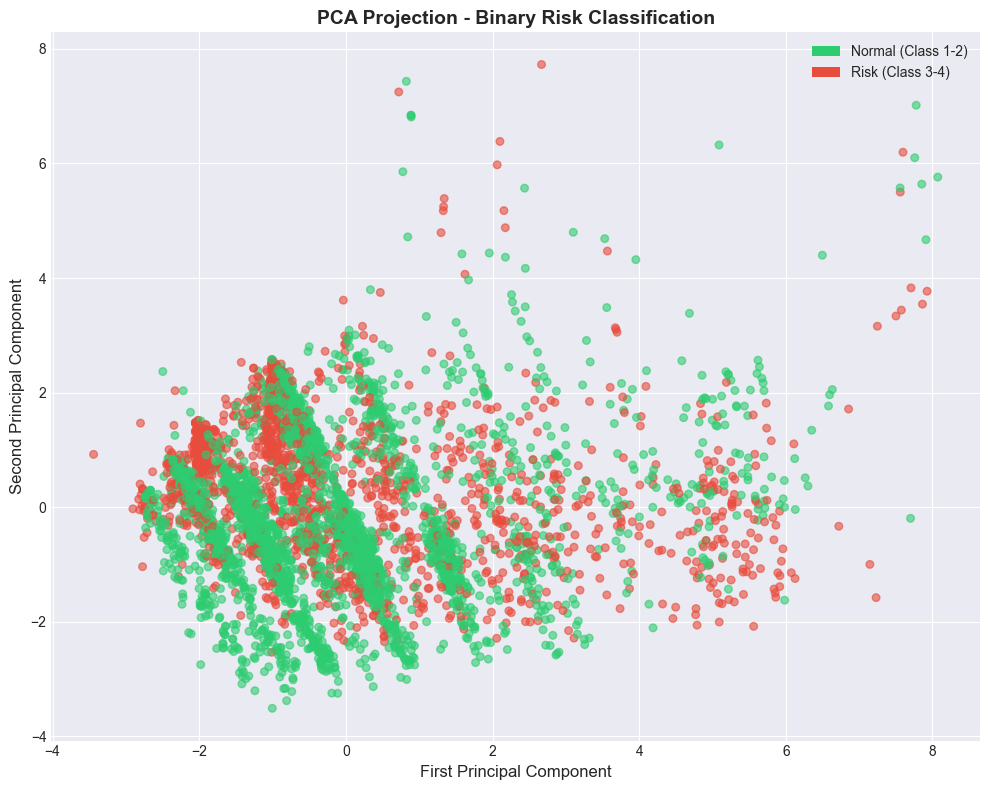

📊 2D PCA explains: 21.6% + 11.3% = 32.9%


In [26]:
# ============================================
# BINARY CLASSIFICATION - PCA VISUALIZATION
# ============================================

print("\n" + "="*80)
print(" PCA VISUALIZATION (Binary Classification)")
print("="*80)

# Use binary target for coloring
y_binary = (y >= 3).astype(int)

# Apply PCA
pca_binary = PCA(n_components=2)
X_pca_binary = pca_binary.fit_transform(X_processed)

# Plot with binary colors
plt.figure(figsize=(10, 8))
colors_binary = ['#2ecc71' if label == 0 else '#e74c3c' for label in y_binary]
scatter = plt.scatter(X_pca_binary[:, 0], X_pca_binary[:, 1], c=colors_binary, alpha=0.6, s=30)
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('PCA Projection - Binary Risk Classification', fontsize=14, fontweight='bold')

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Normal (Class 1-2)'),
                   Patch(facecolor='#e74c3c', label='Risk (Class 3-4)')]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print(f"📊 2D PCA explains: {pca_binary.explained_variance_ratio_[0]*100:.1f}% + {pca_binary.explained_variance_ratio_[1]*100:.1f}% = {pca_binary.explained_variance_ratio_.sum()*100:.1f}%")


 CLUSTERING ANALYSIS (Binary Classification)

📊 Cluster vs Actual Binary Labels:
----------------------------------------

Cluster to Actual Mapping:
Actual          0         1
Cluster                    
0        0.676633  0.323367
1        0.592449  0.407551

📊 Cluster Quality Metrics:
   Adjusted Rand Index: 0.0244
   Homogeneity Score: 0.0042


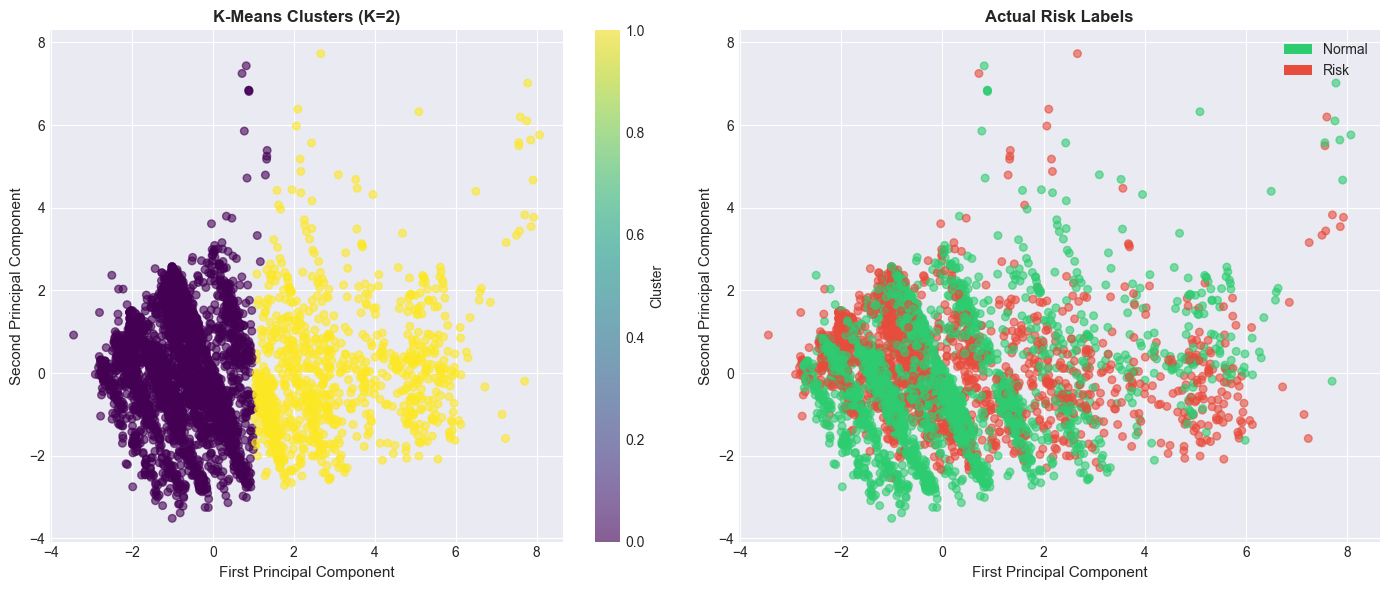


✅ K-Means with 2 clusters completed!


In [27]:
# ============================================
# BINARY CLASSIFICATION - CLUSTERING (K-MEANS)
# ============================================

print("\n" + "="*80)
print(" CLUSTERING ANALYSIS (Binary Classification)")
print("="*80)

# Apply K-Means
kmeans_binary = KMeans(n_clusters=2, random_state=42, n_init=10)  # 2 clusters for binary
clusters_binary = kmeans_binary.fit_predict(X_processed)

# Compare clusters with actual binary labels
from sklearn.metrics import adjusted_rand_score, homogeneity_score

print("\n📊 Cluster vs Actual Binary Labels:")
print("-" * 40)

# Create cross-tabulation
cross_tab = pd.crosstab(clusters_binary, y_binary, 
                         normalize='index', 
                         rownames=['Cluster'], 
                         colnames=['Actual'])
print("\nCluster to Actual Mapping:")
print(cross_tab)

# Calculate agreement metrics
ari = adjusted_rand_score(y_binary, clusters_binary)
homogeneity = homogeneity_score(y_binary, clusters_binary)

print(f"\n📊 Cluster Quality Metrics:")
print(f"   Adjusted Rand Index: {ari:.4f}")
print(f"   Homogeneity Score: {homogeneity:.4f}")

# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: K-Means Clusters
ax1 = axes[0]
scatter1 = ax1.scatter(X_pca_binary[:, 0], X_pca_binary[:, 1], c=clusters_binary, cmap='viridis', alpha=0.6, s=30)
ax1.set_xlabel('First Principal Component', fontsize=11)
ax1.set_ylabel('Second Principal Component', fontsize=11)
ax1.set_title('K-Means Clusters (K=2)', fontsize=12, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# Plot 2: Actual Binary Labels
ax2 = axes[1]
colors_binary_plot = ['#2ecc71' if label == 0 else '#e74c3c' for label in y_binary]
scatter2 = ax2.scatter(X_pca_binary[:, 0], X_pca_binary[:, 1], c=colors_binary_plot, alpha=0.6, s=30)
ax2.set_xlabel('First Principal Component', fontsize=11)
ax2.set_ylabel('Second Principal Component', fontsize=11)
ax2.set_title('Actual Risk Labels', fontsize=12, fontweight='bold')
legend_elements = [Patch(facecolor='#2ecc71', label='Normal'),
                   Patch(facecolor='#e74c3c', label='Risk')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print(f"\n✅ K-Means with 2 clusters completed!")


 STEP 9: ANOMALY DETECTION (Risk vs Normal)
📊 Ground Truth for Anomaly Detection:
   Normal (0): 3,056 samples
   Risk (1 - Anomaly): 1,589 samples

--------------------------------------------------
 9.1 ISOLATION FOREST
--------------------------------------------------

Testing different contamination levels...

   Isolation Forest (15%)... TP:238 FP:459 | F1:0.2082
   Isolation Forest (20%)... TP:307 FP:622 | F1:0.2438
   Isolation Forest (25%)... TP:372 FP:789 | F1:0.2705
   Isolation Forest (30%)... TP:425 FP:969 | F1:0.2849
   Isolation Forest (34%)... TP:480 FP:1099 | F1:0.3030
   Isolation Forest (auto)... TP:0 FP:0 | F1:0.0000

🏆 BEST ISOLATION FOREST: Isolation Forest (34%)
   F1-Score: 0.3030
   TP (Risk caught): 480
   FP (False alarms): 1099


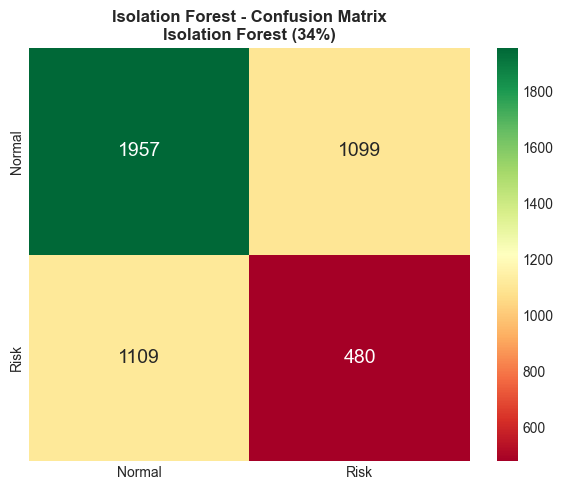


--------------------------------------------------
 9.2 AUTOENCODER
--------------------------------------------------
Training Autoencoder...
✅ Training complete! Best loss: 0.001066

Finding optimal threshold...
   70th percentile: F1=0.4278, TP=638
   75th percentile: F1=0.4044, TP=556
   80th percentile: F1=0.3685, TP=464
   85th percentile: F1=0.2983, TP=341
   90th percentile: F1=0.2152, TP=221
   91th percentile: F1=0.2043, TP=205
   92th percentile: F1=0.1795, TP=176
   93th percentile: F1=0.1608, TP=154
   94th percentile: F1=0.1403, TP=131
   95th percentile: F1=0.1229, TP=112
   96th percentile: F1=0.1025, TP=91
   97th percentile: F1=0.0763, TP=66
   98th percentile: F1=0.0499, TP=42
   99th percentile: F1=0.0293, TP=24

🏆 BEST AUTOENCODER: 70.0th percentile (F1: 0.4278)

📊 Autoencoder Results:
   TP (Risk caught): 638
   FP (False alarms): 756
   FN (Missed risk): 951
   Recall: 0.4015
   Precision: 0.4577
   F1-Score: 0.4278


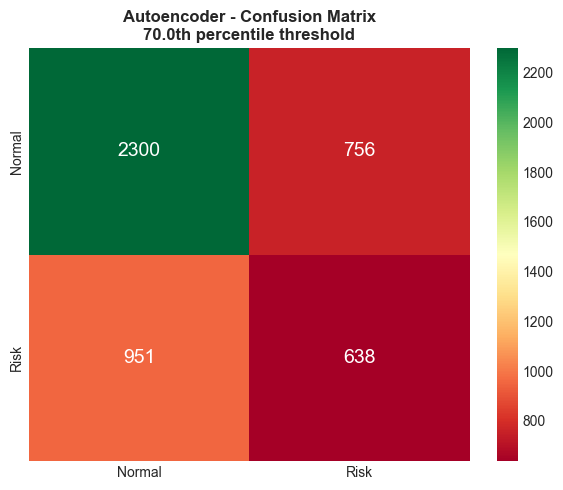

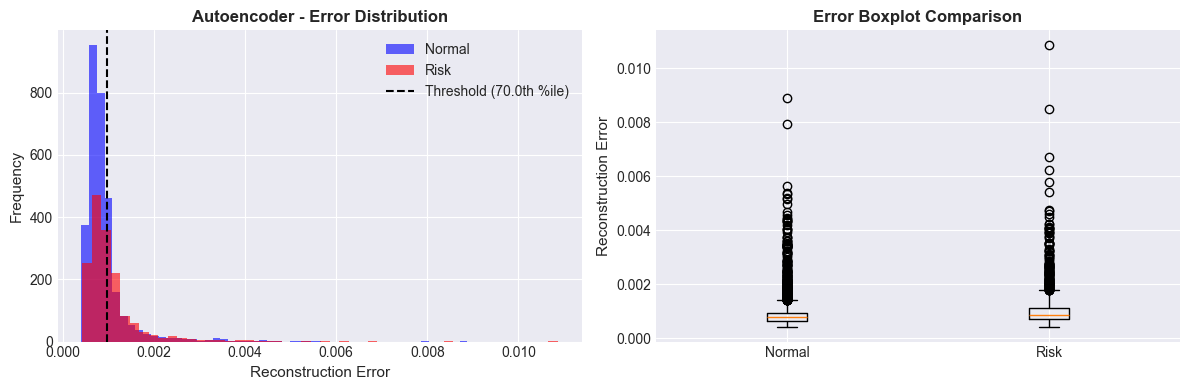


 TABLE 2: ANOMALY DETECTION RESULTS (Binary Consistent)

+-----+------------------+-------+-------+-------+--------+----------+
| No. | Model            | TP    | FP    | FN    | Recall | F1-Score |
+-----+------------------+-------+-------+-------+--------+----------+
| 1   | Isolation Forest |   480 |  1099 |  1109 | 0.3021 | 0.3030  |
| 2   | Autoencoder      |   638 |   756 |   951 | 0.4015 | 0.4278  |
+-----+------------------+-------+-------+-------+--------+----------+

 TABLE 3: ALL MODELS COMPARISON (Binary Consistent)

+-----+----------------------+----------------------+----------+-------+-------+
| No. | Model                | Type                 | F1-Score | TP    | FP    |
+-----+----------------------+----------------------+----------+-------+-------+
|  1  | Logistic Regression  | Supervised           | 0.9464   |   nan |   nan |
|  2  | Decision Tree        | Supervised           | 0.8824   |   nan |   nan |
|  3  | Naive Bayes          | Supervised           | 0.759

In [30]:
# ============================================
# STEP 9: ANOMALY DETECTION (BINARY CONSISTENT)
# Using Risk_Binary as ground truth for evaluation
# ============================================

print("\n" + "="*80)
print(" STEP 9: ANOMALY DETECTION (Risk vs Normal)")
print("="*80)

# Use Risk_Binary as ground truth
y_anomaly_truth = y_binary  # 1 = Risk (anomaly), 0 = Normal

print(f"📊 Ground Truth for Anomaly Detection:")
print(f"   Normal (0): {(y_anomaly_truth == 0).sum():,} samples")
print(f"   Risk (1 - Anomaly): {(y_anomaly_truth == 1).sum():,} samples")

# ============================================
# 9.1 ISOLATION FOREST
# ============================================

print("\n" + "-"*50)
print(" 9.1 ISOLATION FOREST")
print("-"*50)

from sklearn.ensemble import IsolationForest

# Test different contamination levels
iso_models = {
    'Isolation Forest (15%)': IsolationForest(contamination=0.15, random_state=42),
    'Isolation Forest (20%)': IsolationForest(contamination=0.20, random_state=42),
    'Isolation Forest (25%)': IsolationForest(contamination=0.25, random_state=42),
    'Isolation Forest (30%)': IsolationForest(contamination=0.30, random_state=42),
    'Isolation Forest (34%)': IsolationForest(contamination=0.34, random_state=42),  # Matches actual risk %
    'Isolation Forest (auto)': IsolationForest(contamination='auto', random_state=42)
}

iso_results = []

print("\nTesting different contamination levels...\n")

for name, iso_model in iso_models.items():
    print(f"   {name}...", end=" ", flush=True)
    
    iso_predictions = iso_model.fit_predict(X_processed)
    # Convert: -1 = anomaly (Risk), 1 = normal
    iso_binary = (iso_predictions == -1).astype(int)
    
    # Calculate metrics against ground truth
    tn, fp, fn, tp = confusion_matrix(y_anomaly_truth, iso_binary).ravel()
    accuracy = accuracy_score(y_anomaly_truth, iso_binary)
    precision = precision_score(y_anomaly_truth, iso_binary, zero_division=0)
    recall = recall_score(y_anomaly_truth, iso_binary, zero_division=0)
    f1 = f1_score(y_anomaly_truth, iso_binary, zero_division=0)
    anomaly_pct = (iso_binary.sum() / len(iso_binary)) * 100
    
    iso_results.append({
        'Model': name,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Anomaly %': round(anomaly_pct, 2)
    })
    
    print(f"TP:{tp} FP:{fp} | F1:{f1:.4f}")

# Best Isolation Forest
iso_df = pd.DataFrame(iso_results).sort_values('F1', ascending=False)
best_iso = iso_df.iloc[0]

print(f"\n🏆 BEST ISOLATION FOREST: {best_iso['Model']}")
print(f"   F1-Score: {best_iso['F1']:.4f}")
print(f"   TP (Risk caught): {best_iso['TP']}")
print(f"   FP (False alarms): {best_iso['FP']}")

# Best model details
best_iso_model = iso_models[best_iso['Model']]
best_iso_pred = best_iso_model.predict(X_processed)
best_iso_binary = (best_iso_pred == -1).astype(int)

# Confusion Matrix
cm_iso = confusion_matrix(y_anomaly_truth, best_iso_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Normal', 'Risk'],
            yticklabels=['Normal', 'Risk'],
            annot_kws={'size': 14})
plt.title(f'Isolation Forest - Confusion Matrix\n{best_iso["Model"]}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 9.2 AUTOENCODER
# ============================================

print("\n" + "-"*50)
print(" 9.2 AUTOENCODER")
print("-"*50)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_processed.shape[1]
encoding_dim = 16

autoencoder = Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(encoding_dim, activation='relu', name='bottleneck'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Autoencoder...")
history = autoencoder.fit(
    X_processed, X_processed,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"✅ Training complete! Best loss: {min(history.history['val_loss']):.6f}")

# Calculate reconstruction errors
reconstructions = autoencoder.predict(X_processed, verbose=0)
reconstruction_errors = np.mean((X_processed - reconstructions) ** 2, axis=1)

# Find optimal threshold (maximizing F1 against ground truth)
thresholds_to_test = [70, 75, 80, 85, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
ae_results = []

print("\nFinding optimal threshold...")

for pct in thresholds_to_test:
    threshold_test = np.percentile(reconstruction_errors, pct)
    ae_binary_test = (reconstruction_errors > threshold_test).astype(int)
    f1_test = f1_score(y_anomaly_truth, ae_binary_test, zero_division=0)
    tp_test = confusion_matrix(y_anomaly_truth, ae_binary_test).ravel()[3] if len(confusion_matrix(y_anomaly_truth, ae_binary_test).ravel()) == 4 else 0
    
    ae_results.append({
        'Threshold %': pct,
        'F1': f1_test,
        'TP': tp_test
    })
    
    print(f"   {pct}th percentile: F1={f1_test:.4f}, TP={tp_test}")

# Best Autoencoder
ae_df = pd.DataFrame(ae_results).sort_values('F1', ascending=False)
best_ae_threshold = ae_df.iloc[0]['Threshold %']
best_ae_f1 = ae_df.iloc[0]['F1']

print(f"\n🏆 BEST AUTOENCODER: {best_ae_threshold}th percentile (F1: {best_ae_f1:.4f})")

# Use best threshold
threshold = np.percentile(reconstruction_errors, best_ae_threshold)
ae_binary = (reconstruction_errors > threshold).astype(int)

# Calculate metrics
tn_ae, fp_ae, fn_ae, tp_ae = confusion_matrix(y_anomaly_truth, ae_binary).ravel()
accuracy_ae = accuracy_score(y_anomaly_truth, ae_binary)
precision_ae = precision_score(y_anomaly_truth, ae_binary, zero_division=0)
recall_ae = recall_score(y_anomaly_truth, ae_binary, zero_division=0)
f1_ae = f1_score(y_anomaly_truth, ae_binary, zero_division=0)
anomaly_pct_ae = (ae_binary.sum() / len(ae_binary)) * 100

print(f"\n📊 Autoencoder Results:")
print(f"   TP (Risk caught): {tp_ae}")
print(f"   FP (False alarms): {fp_ae}")
print(f"   FN (Missed risk): {fn_ae}")
print(f"   Recall: {recall_ae:.4f}")
print(f"   Precision: {precision_ae:.4f}")
print(f"   F1-Score: {f1_ae:.4f}")

# Confusion Matrix
cm_ae = confusion_matrix(y_anomaly_truth, ae_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Normal', 'Risk'],
            yticklabels=['Normal', 'Risk'],
            annot_kws={'size': 14})
plt.title(f'Autoencoder - Confusion Matrix\n{best_ae_threshold}th percentile threshold', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Error distribution plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(reconstruction_errors[y_anomaly_truth == 0], bins=50, alpha=0.6, label='Normal', color='blue')
plt.hist(reconstruction_errors[y_anomaly_truth == 1], bins=50, alpha=0.6, label='Risk', color='red')
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold ({best_ae_threshold}th %ile)')
plt.xlabel('Reconstruction Error', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Autoencoder - Error Distribution', fontsize=12, fontweight='bold')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([reconstruction_errors[y_anomaly_truth == 0], reconstruction_errors[y_anomaly_truth == 1]], 
            labels=['Normal', 'Risk'])
plt.ylabel('Reconstruction Error', fontsize=11)
plt.title('Error Boxplot Comparison', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# STEP 10: UNSUPERVISED MODELS COMPARISON TABLE
# ============================================

print("\n" + "="*80)
print(" TABLE 2: ANOMALY DETECTION RESULTS (Binary Consistent)")
print("="*80)

unsupervised_comparison = pd.DataFrame([
    {'Model': 'Isolation Forest', 'TP': best_iso['TP'], 'FP': best_iso['FP'], 
     'FN': best_iso['FN'], 'Recall': best_iso['Recall'], 'F1': best_iso['F1']},
    {'Model': 'Autoencoder', 'TP': tp_ae, 'FP': fp_ae, 'FN': fn_ae,
     'Recall': recall_ae, 'F1': f1_ae}
])

print("\n+-----+------------------+-------+-------+-------+--------+----------+")
print("| No. | Model            | TP    | FP    | FN    | Recall | F1-Score |")
print("+-----+------------------+-------+-------+-------+--------+----------+")

for idx, row in unsupervised_comparison.iterrows():
    print(f"| {idx+1}   | {row['Model']:<16} | {row['TP']:>5} | {row['FP']:>5} | {row['FN']:>5} | {row['Recall']:.4f} | {row['F1']:.4f}  |")

print("+-----+------------------+-------+-------+-------+--------+----------+")

# ============================================
# STEP 11: COMBINED COMPARISON - ALL MODELS
# ============================================

print("\n" + "="*80)
print(" TABLE 3: ALL MODELS COMPARISON (Binary Consistent)")
print("="*80)

# Combine supervised and unsupervised
all_models_comparison = []

# Add supervised models
for _, row in binary_results_df.iterrows():
    all_models_comparison.append({
        'Model': row['Model'],
        'Type': 'Supervised',
        'F1-Score': row['F1-Score'],
        'TP': None,  # Supervised models use different confusion matrix
        'FP': None
    })

# Add unsupervised models
for _, row in unsupervised_comparison.iterrows():
    all_models_comparison.append({
        'Model': row['Model'],
        'Type': 'Unsupervised (Anomaly Detection)',
        'F1-Score': row['F1'],
        'TP': row['TP'],
        'FP': row['FP']
    })

all_models_df = pd.DataFrame(all_models_comparison).sort_values('F1-Score', ascending=False)

print("\n+-----+----------------------+----------------------+----------+-------+-------+")
print("| No. | Model                | Type                 | F1-Score | TP    | FP    |")
print("+-----+----------------------+----------------------+----------+-------+-------+")

for idx, row in all_models_df.iterrows():
    tp_str = str(row['TP']) if row['TP'] is not None else '-'
    fp_str = str(row['FP']) if row['FP'] is not None else '-'
    print(f"| {idx+1:2d}  | {row['Model']:<20} | {row['Type']:<20} | {row['F1-Score']:.4f}   | {tp_str:>5} | {fp_str:>5} |")

print("+-----+----------------------+----------------------+----------+-------+-------+")

# Best overall
best_overall = all_models_df.iloc[0]
print(f"\n🏆 BEST OVERALL MODEL: {best_overall['Model']} (F1: {best_overall['F1-Score']:.4f})")